# Giai đoạn 4 — Mốc chuẩn M₀: huấn luyện CHỈ trên phiếu khảo sát

```
┌────────────────────────────────────────────────────────────────────────────┐
│                                04_MocChuan                                 │
└────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 03_TachTrainTest/khaosat_train.csv  —  574 phiếu thật
    • 03_TachTrainTest/cv_folds.json      —  15 fold
         │
         ▼
  XỬ LÝ
    1. Dựng 63 đặc trưng từ 574 phiếu khảo sát
    2. Huấn luyện qua 15 fold — KHÔNG dùng TTTH, KHÔNG dùng dữ liệu sinh thêm
    3. So mô hình chung với mô hình riêng từng khối
    4. Đo Top-1/2/3/5 ở cả hai chế độ, LUÔN kèm mốc đoán bừa
    5. Đo thêm trên chính tập train để thấy mức nhớ vẹt
         │
         ▼
  ĐẦU RA
    • 04_MocChuan/moc_chuan.json          —  mốc M₀ cho các giai đoạn sau
    • 04_MocChuan/moc_chuan_theo_khoi.csv
    • 04_MocChuan/hinh_4_*.png            —  3 hình
```

## Đây là con số mà mọi bước sau phải vượt

Giai đoạn 6 sẽ sinh thêm hàng nghìn dòng dữ liệu. Không có M₀ thì không trả lời được câu hỏi duy
nhất đáng hỏi: **thêm dữ liệu đó có thật sự giúp gì không?**

## Mô hình: XGBoost phân loại, không có gì khác

Giải thích trong một câu:

```
mô hình cho ra XÁC SUẤT cho từng ngành trong 39 ngành
   → bỏ những ngành không thuộc nhóm người dùng chọn
      → lấy 3 ngành xác suất cao nhất còn lại
```

Đúng cách web gọi API:

| Chế độ web | `fieldId` | Mô hình làm gì | Ý nghĩa con số |
|---|---|---|---|
| **Khám phá** | `null` | xếp hạng cả 39 ngành | **năng lực thật của hệ thống** |
| **Tư vấn** | `0..6` | chỉ xếp hạng ngành trong khối đã chọn | chỉ số **có điều kiện** |

Web gửi `limit: 3` nên **Top-3 là chỉ tiêu chính**.

## Vì sao mọi bảng đều có cột "đoán bừa"

Khối *Luật* và *Ngoại ngữ* chỉ có **2 ngành**. Gợi ý 3 ngành cho một khối 2 ngành thì **luôn đúng
100%** mà không cần mô hình nào cả. Nếu chỉ báo cáo độ chính xác trần trụi, một con số 85% có thể
chỉ hơn đoán bừa vài điểm. Cột `hơn` mới cho biết mô hình đóng góp bao nhiêu.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

OUT = thu_muc(4)

D = nap(co_ttth=True)          # TTTH chỉ dùng để lấy danh sách tổ hợp + thống kê điểm
ks = D["train"]
X = dac_trung(ks, D).values
y = ks.ma_nganh.values
NG = D["nganh"]
nhom_sv = np.array([D["nhom"][m] for m in y])
FOLDS = D["folds"]["folds"]
K = len(D["ten_nhom"])
co_nhom = pd.Series(list(D["nhom"].values())).value_counts()

print(f"Dữ liệu   : {len(ks)} phiếu khảo sát thật · {X.shape[1]} đặc trưng")
print(f"Nhãn      : {len(NG)} ngành → {K} {D['ten_cach_nhom']}")
print(f"Cỡ khối   : {sorted(co_nhom.values, reverse=True)}")
print(f"Cross-val : {D['folds']['n_splits']} fold × {D['folds']['n_repeats']} lần lặp"
      f" = {len(FOLDS)} lần đo")

Dữ liệu   : 574 phiếu khảo sát thật · 63 đặc trưng
Nhãn      : 39 ngành → 9 nhóm ngành (chia lại)
Cỡ khối   : [7, 6, 4, 4, 4, 4, 4, 3, 3]
Cross-val : 5 fold × 3 lần lặp = 15 lần đo


## 1. Chạy cross-validation

In [2]:
def chay_cv(rieng_nhom=False, hp=None, hp_nhom=None, do_train=False):
    """Một lượt CV đầy đủ, gộp dự đoán của cả 15 fold.

    VAL luôn chỉ gồm phiếu khảo sát thật — về sau khi có dữ liệu sinh thêm,
    chúng chỉ được vào phía TRAIN, nếu không thì mô hình được chấm điểm trên
    chính dữ liệu do nó gián tiếp sinh ra.
    """
    g = {k: [] for k in ("auto", "guided", "y", "auto_tr", "guided_tr", "y_tr")}
    for f in FOLDS:
        tr, va = np.array(f["train_idx"]), np.array(f["val_idx"])
        mh = MoHinhNganh(D, hp, rieng_nhom, hp_nhom).fit(X[tr], y[tr])
        g["auto"].append(mh.diem(X[va]))
        g["guided"].append(mh.diem(X[va], nhom_sv[va]))
        g["y"].append(y[va])
        if do_train:
            g["auto_tr"].append(mh.diem(X[tr]))
            g["guided_tr"].append(mh.diem(X[tr], nhom_sv[tr]))
            g["y_tr"].append(y[tr])
    return {k: (np.concatenate(v) if k.startswith("y") else np.vstack(v))
            for k, v in g.items() if v}


t0 = time.time()
kq = chay_cv(do_train=True)
print(f"Mô hình chung  : {len(FOLDS)} fold trong {time.time()-t0:.0f}s")

y_all = kq["y"]
auto = top_k(kq["auto"], y_all, NG)
guided = top_k(kq["guided"], y_all, NG)
bua_auto = bua_toan_bo(len(NG))
bua_guided = bua_trong_nhom(y_all, D["nhom"])

tr_auto = top_k(kq["auto_tr"], kq["y_tr"], NG)
tr_guided = top_k(kq["guided_tr"], kq["y_tr"], NG)
print(f"   tư vấn Top-3 {guided[3]:.1%} · khám phá Top-3 {auto[3]:.1%}")

Mô hình chung  : 15 fold trong 167s
   tư vấn Top-3 83.2% · khám phá Top-3 35.4%


## 2. Mô hình chung so với mô hình riêng từng khối

Mô hình chung phải trải sức phân biệt **mọi cặp ngành** trong 39 ngành — kể cả cặp *Luật* với *Công
nghệ thực phẩm*, hai ngành mà thực tế không bao giờ phải đem ra so với nhau.

Mô hình riêng chỉ học đúng việc cần làm: phân biệt vài ngành **trong cùng một khối**.

In [3]:
t0 = time.time()
kq_r = chay_cv(rieng_nhom=True, do_train=True)
print(f"Mô hình riêng khối: {len(FOLDS)} fold trong {time.time()-t0:.0f}s\n")

guided_r = top_k(kq_r["guided"], kq_r["y"], NG)
tr_guided_r = top_k(kq_r["guided_tr"], kq_r["y_tr"], NG)

in_bang([dong("Một mô hình chung cho 39 ngành", guided, bua_guided),
         dong("Mỗi khối một mô hình riêng", guided_r, bua_guided)],
        "CHẾ ĐỘ TƯ VẤN — hai cách dựng mô hình")
chenh = {k: guided_r[k] - guided[k] for k in TOP_K}
print("\nChênh: " + " · ".join(f"Top-{k} {chenh[k]*100:+.1f}đ" for k in TOP_K))

if chenh[3] > 0:
    print("\n→ Mô hình riêng khối thắng. Các giai đoạn sau dùng cách này.")
    RIENG, guided_c, tr_guided_c = True, guided_r, tr_guided_r
else:
    print("\n→ Mô hình chung vẫn hơn, giữ nguyên.")
    RIENG, guided_c, tr_guided_c = False, guided, tr_guided

Mô hình riêng khối: 15 fold trong 300s

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
CHẾ ĐỘ TƯ VẤN — hai cách dựng mô hình
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                             Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Một mô hình chung cho 39 ngành      40.7%   23.3%   +17.3đ    22.6%    65.2%   46.7%   +18.6đ    34.8%    83.2%   70.0%   +13.2đ    43.9%    97.3%   93.1%    +4.1đ    60.3%
Mỗi khối một mô hình riêng          42.6%   23.3%   +19.2

In [4]:
in_bang([dong("Khám phá (auto) — xếp hạng cả 39 ngành", auto, bua_auto),
         dong("Tư vấn (guided) — trong khối người dùng chọn", guided_c, bua_guided)],
        f"MỐC CHUẨN M₀ — chỉ {len(ks)} phiếu khảo sát, không dữ liệu bổ sung")
print("\nHai chế độ KHÔNG so ngang hàng được: chế độ tư vấn đã được người dùng cho")
print("biết khối ngành, tức đã giải sẵn phần khó nhất của bài toán.\n")

bang_train_test([("Tư vấn (người dùng chọn khối)", tr_guided_c, guided_c, bua_guided),
                 ("Khám phá (không chọn khối)", tr_auto, auto, bua_auto)])
print("\nChênh train − val lớn là đặc tính của XGBoost trên 574 dòng: cây quyết định")
print("nhớ được phần lớn tập huấn luyện. Giai đoạn 9 sẽ siết lại bằng điều hoà.")

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
MỐC CHUẨN M₀ — chỉ 574 phiếu khảo sát, không dữ liệu bổ sung
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                                           Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Khám phá (auto) — xếp hạng cả 39 ngành            15.9%    2.6%   +13.3đ    13.7%    26.5%    5.1%   +21.4đ    22.5%    35.4%    7.7%   +27.7đ    30.0%    46.9%   12.8%   +34.0đ    39.1%
Tư v

   💾 hinh_4_1_moc_chuan.png


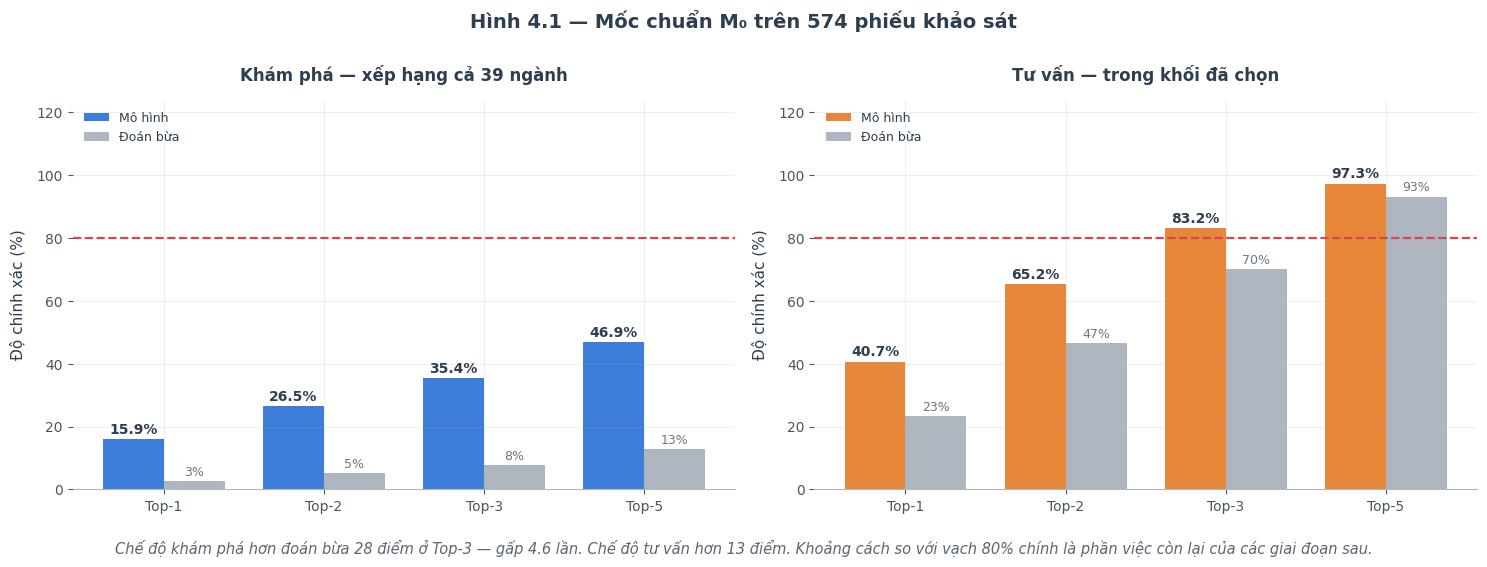

In [5]:
# ═══════════ HÌNH 4.1 — Mốc chuẩn so với đoán bừa ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.2))
kk = list(TOP_K); x = np.arange(len(kk)); w = .38
for ax, (r, b, ten, mau) in zip((a1, a2), [
        (auto, bua_auto, "Khám phá — xếp hạng cả 39 ngành", C_XANH),
        (guided_c, bua_guided, "Tư vấn — trong khối đã chọn", C_CAM)]):
    ax.bar(x - w/2, [r[k]*100 for k in kk], w, color=mau, label="Mô hình")
    ax.bar(x + w/2, [b[k]*100 for k in kk], w, color=C_XAM, label="Đoán bừa")
    ax.set_xticks(x); ax.set_xticklabels([f"Top-{k}" for k in kk])
    ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 105)
    ax.set_title(ten, fontsize=12)
    cho_chu_giai(ax, ngang=False, phan=.18)
    ax.legend(loc="upper left", framealpha=.95, fontsize=9)
    ax.axhline(80, color=C_THAT, ls="--", lw=1.6)
    for i, k in enumerate(kk):
        ax.text(i - w/2, r[k]*100 + 1.8, f"{r[k]:.1%}", ha="center",
                fontweight="bold", fontsize=10)
        ax.text(i + w/2, b[k]*100 + 1.8, f"{b[k]:.0%}", ha="center", fontsize=9,
                color="#6B7680")
fig.suptitle(f"Hình 4.1 — Mốc chuẩn M₀ trên {len(ks)} phiếu khảo sát",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_4_1_moc_chuan.png",
    f"Chế độ khám phá hơn đoán bừa {(auto[3]-bua_auto[3])*100:.0f} điểm ở Top-3 — gấp "
    f"{auto[3]/bua_auto[3]:.1f} lần. Chế độ tư vấn hơn {(guided_c[3]-bua_guided[3])*100:.0f} điểm. "
    "Khoảng cách so với vạch 80% chính là phần việc còn lại của các giai đoạn sau.")
plt.show()

   💾 hinh_4_2_theo_khoi.png


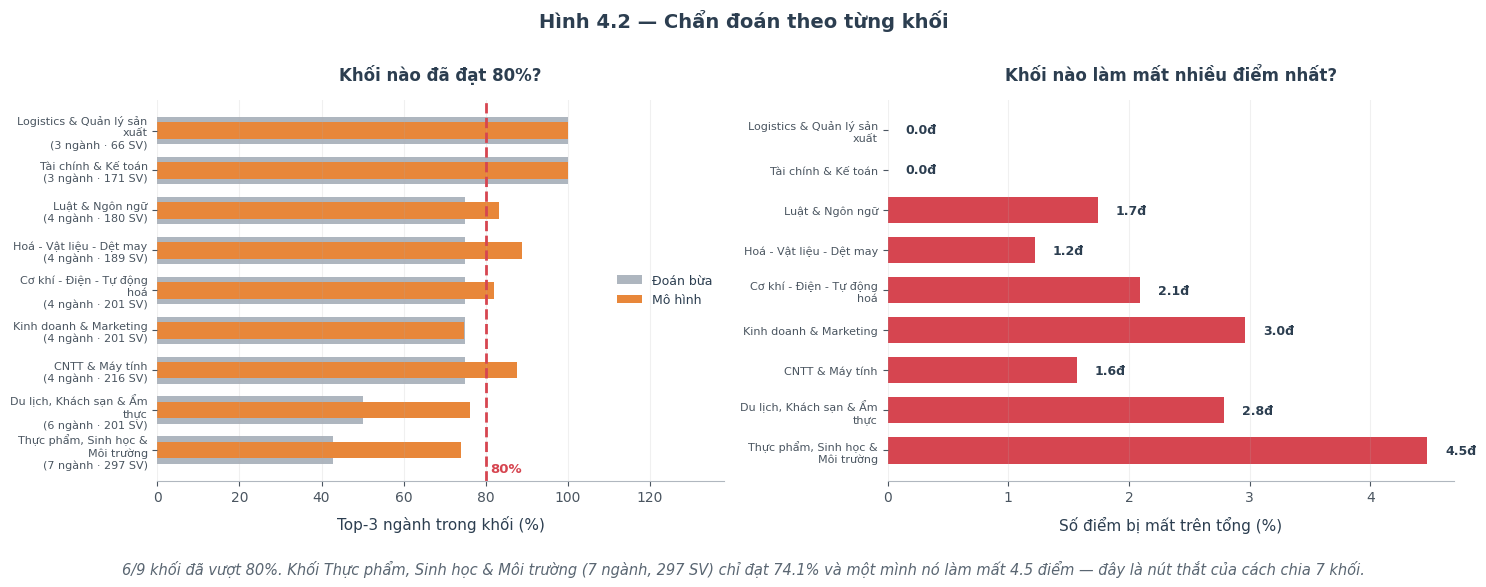

In [6]:
# ═══════════ HÌNH 4.2 — Kết quả theo từng khối ═══════════
S_g = kq_r["guided"] if RIENG else kq["guided"]
theo = []
for g in range(K):
    sel = np.array([D["nhom"][m] == g for m in y_all])
    if not sel.any():
        continue
    o = np.argsort(-S_g[sel], 1)
    yy = y_all[sel]
    t3 = float(np.mean([yy[i] in NG[o[i, :3]] for i in range(int(sel.sum()))]))
    b3 = min(3, co_nhom[g]) / co_nhom[g]
    theo.append({"ma_khoi": g, "khoi": D["ten_nhom"][g], "n_nganh": int(co_nhom[g]),
                 "n_sv": int(sel.sum()), "top3": t3, "bua3": b3, "hon": t3 - b3,
                 "mat": (1 - t3) * sel.mean()})
tk = pd.DataFrame(theo).sort_values("n_nganh", ascending=False)
tk.to_csv(OUT / "moc_chuan_theo_khoi.csv", index=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.4))
yy = np.arange(len(tk))
a1.barh(yy, tk.bua3 * 100, color=C_XAM, height=.68, label="Đoán bừa")
a1.barh(yy, tk.top3 * 100, color=C_CAM, height=.42, label="Mô hình")
a1.axvline(80, color=C_THAT, ls="--", lw=2)
a1.text(81, -.55, "80%", fontsize=9.5, color=C_THAT, fontweight="bold")
a1.set_yticks(yy)
a1.set_yticklabels([f"{ngat_dong(r.khoi, 24)}\n({r.n_nganh} ngành · {r.n_sv} SV)"
                    for r in tk.itertuples()], fontsize=8)
a1.set_xlabel("Top-3 ngành trong khối (%)"); a1.set_xlim(0, 138)
a1.set_title("Khối nào đã đạt 80%?", fontsize=12)
a1.legend(loc="center right", fontsize=9, framealpha=.95)
a1.grid(axis="y", alpha=0)

a2.barh(yy, tk.mat * 100, color=C_THAT, height=.66)
a2.set_yticks(yy); a2.set_yticklabels([ngat_dong(r.khoi, 24) for r in tk.itertuples()], fontsize=8)
a2.set_xlabel("Số điểm bị mất trên tổng (%)")
a2.set_title("Khối nào làm mất nhiều điểm nhất?", fontsize=12); a2.grid(axis="y", alpha=0)
for i, v in enumerate(tk.mat * 100):
    a2.text(v + .15, i, f"{v:.1f}đ", va="center", fontsize=9, fontweight="bold")

fig.suptitle("Hình 4.2 — Chẩn đoán theo từng khối", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
xau = tk.loc[tk.mat.idxmax()]
dat80 = tk[tk.top3 >= .8]
luu(fig, OUT, "hinh_4_2_theo_khoi.png",
    f"{len(dat80)}/{len(tk)} khối đã vượt 80%. Khối {xau.khoi} ({xau.n_nganh} ngành, "
    f"{xau.n_sv} SV) chỉ đạt {xau.top3:.1%} và một mình nó làm mất {xau.mat*100:.1f} điểm — "
    "đây là nút thắt của cách chia 7 khối.")
plt.show()

   💾 hinh_4_3_nho_vet.png


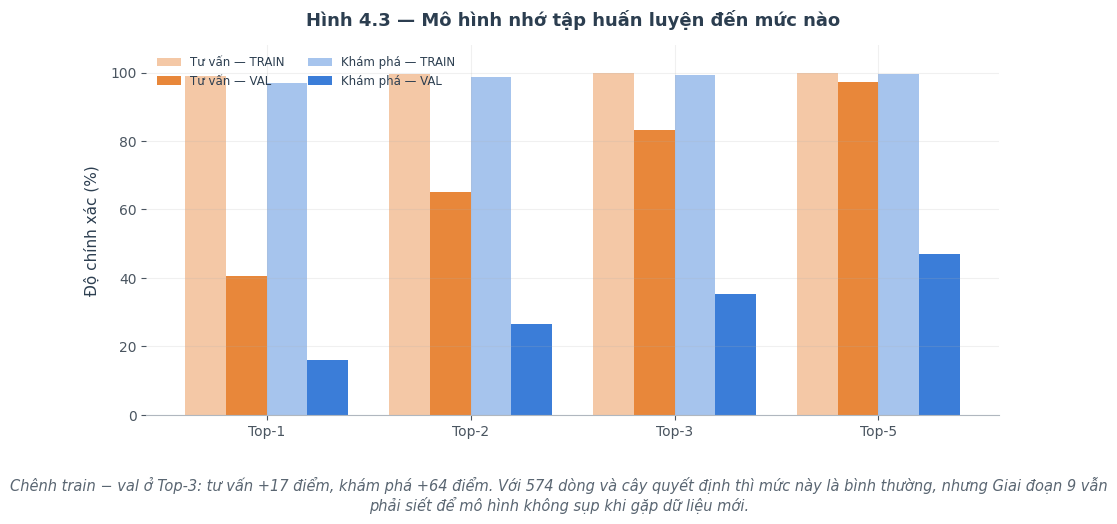

In [7]:
# ═══════════ HÌNH 4.3 — Nhớ vẹt ═══════════
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(TOP_K)); w = .2
for j, (tr_, te_, ten, mau) in enumerate([
        (tr_guided_c, guided_c, "Tư vấn", C_CAM),
        (tr_auto, auto, "Khám phá", C_XANH)]):
    ax.bar(x + (j*2-1.5)*w, [tr_[k]*100 for k in TOP_K], w, color=mau, alpha=.45,
           label=f"{ten} — TRAIN")
    ax.bar(x + (j*2-0.5)*w, [te_[k]*100 for k in TOP_K], w, color=mau,
           label=f"{ten} — VAL")
ax.set_xticks(x); ax.set_xticklabels([f"Top-{k}" for k in TOP_K])
ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 108)
ax.set_title("Hình 4.3 — Mô hình nhớ tập huấn luyện đến mức nào")
ax.legend(fontsize=8.5, ncol=2)
luu(fig, OUT, "hinh_4_3_nho_vet.png",
    f"Chênh train − val ở Top-3: tư vấn {(tr_guided_c[3]-guided_c[3])*100:+.0f} điểm, khám phá "
    f"{(tr_auto[3]-auto[3])*100:+.0f} điểm. Với 574 dòng và cây quyết định thì mức này là bình "
    "thường, nhưng Giai đoạn 9 vẫn phải siết để mô hình không sụp khi gặp dữ liệu mới.")
plt.show()

## 3. Xuất mốc chuẩn

In [8]:
(OUT / "moc_chuan.json").write_text(json.dumps({
    "n_train": len(ks), "n_dac_trung": int(X.shape[1]),
    "n_fold": len(FOLDS), "rieng_nhom": bool(RIENG),
    "auto": {"top": auto, "bua": bua_auto, "tren_train": tr_auto},
    "guided": {"top": guided_c, "bua": bua_guided, "tren_train": tr_guided_c},
    "guided_chung": guided, "guided_rieng_khoi": guided_r,
    "chenh_rieng_vs_chung": chenh,
    "gap_train_val": {"auto": {k: tr_auto[k] - auto[k] for k in TOP_K},
                      "guided": {k: tr_guided_c[k] - guided_c[k] for k in TOP_K}},
    "theo_khoi": tk.to_dict("records"),
}, ensure_ascii=False, indent=2, default=float), encoding="utf-8")

tom_tat("GIAI ĐOẠN 4 — MỐC CHUẨN M₀", [
    f"Dữ liệu                {len(ks)} phiếu khảo sát · {X.shape[1]} đặc trưng",
    f"Cách dựng mô hình      {'mỗi khối một mô hình riêng' if RIENG else 'một mô hình chung'}"
    f"  ({chenh[3]*100:+.1f}đ so với cách kia)",
    "",
    "CHẾ ĐỘ TƯ VẤN (người dùng chọn khối)",
] + [f"   Top-{k}: {guided_c[k]:6.1%}   bừa {bua_guided[k]:5.1%}"
     f"   hơn {(guided_c[k]-bua_guided[k])*100:+5.1f}đ" for k in TOP_K] + [
    "",
    "CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)",
] + [f"   Top-{k}: {auto[k]:6.1%}   bừa {bua_auto[k]:5.1%}"
     f"   gấp {auto[k]/bua_auto[k]:4.1f} lần" for k in TOP_K] + [
    "",
    f"Khối đã đạt 80%        {len(dat80)}/{len(tk)}",
    f"Nút thắt               {xau.khoi} — {xau.n_nganh} ngành, {xau.top3:.1%}",
])
print(f"\n✅ moc_chuan.json · moc_chuan_theo_khoi.csv · 3 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                         GIAI ĐOẠN 4 — MỐC CHUẨN M₀                         ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Dữ liệu                574 phiếu khảo sát · 63 đặc trưng                   ║
║ Cách dựng mô hình      một mô hình chung  (-0.2đ so với cách kia)          ║
║                                                                            ║
║ CHẾ ĐỘ TƯ VẤN (người dùng chọn khối)                                       ║
║    Top-1:  40.7%   bừa 23.3%   hơn +17.3đ                                  ║
║    Top-2:  65.2%   bừa 46.7%   hơn +18.6đ                                  ║
║    Top-3:  83.2%   bừa 70.0%   hơn +13.2đ                                  ║
║    Top-5:  97.3%   bừa 93.1%   hơn  +4.1đ                                  ║
║                                                                            ║
║ CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)                 